### Perform Clustering

In [1]:
# Imports
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import joblib

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
from clustering import Cluster
from yaml_processor import load_config, save_config
from data_processing import load_dataset, save_dataset, save_cluster, parameter_plot
from sensor_processing_v2 import sensor_processing

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

##### Initialization

In [2]:
bounds = config_global["data"]["param_bounds"]
param_bounds = []
for key in bounds.keys():
    param_bounds.append([min(bounds[key]), max(bounds[key])])

In [3]:
# Minimum number of data points in each cluster
n_train_per_cluster = 16
n_val_per_cluster = 8
n_test_per_cluster = 64
normalize = False

In [4]:
dataset_path = os.path.join(output_dir, "datasets")
FS_train, param_train, ft_train, disp_norm, vel_norm, ft_norm = load_dataset(os.path.join(dataset_path, "Train"), normalize=normalize)
FS_val, param_val, ft_val, _, _, _ = load_dataset(os.path.join(dataset_path, "Val"), normalize, disp_norm, vel_norm, ft_norm)
FS_test, param_test, ft_test, _, _, _ = load_dataset(os.path.join(dataset_path, "Test"), normalize, disp_norm, vel_norm, ft_norm)

In [5]:
# Apply Sensor Placement
sp = sensor_processing(FS_train[:, 1], config_global)
A_Mat, C_Mat, pinv_Theta, sensor_placement = sp.load(output_dir)
RS_train, RS_val, RS_test = sp.apply_sensors(FS_train, FS_val, FS_test)

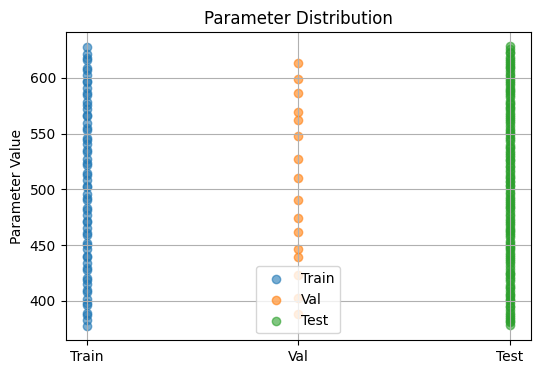

In [6]:
parameter_plot(param_train, param_val, param_test)

Perform Clustering

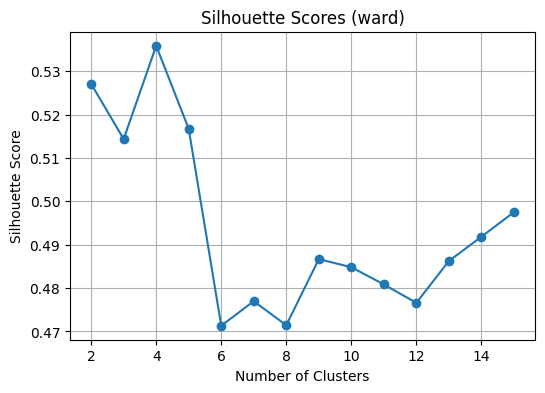

k=2, silhouette=0.527
k=3, silhouette=0.514
k=4, silhouette=0.536
k=5, silhouette=0.517
k=6, silhouette=0.471
k=7, silhouette=0.477
k=8, silhouette=0.471
k=9, silhouette=0.487
k=10, silhouette=0.485
k=11, silhouette=0.481
k=12, silhouette=0.477
k=13, silhouette=0.486
k=14, silhouette=0.492
k=15, silhouette=0.497


In [7]:
clust = Cluster(param_train, RS_train[:, 1], bounds=param_bounds, seed=config_global["seed"])
sil_scores = clust.find_best_k_by_silhouette(k_range=range(2, 16), method="ward")

Choose optimal number of clusters

In [8]:
idxs = np.argsort(ft_train[:, 0, 1])

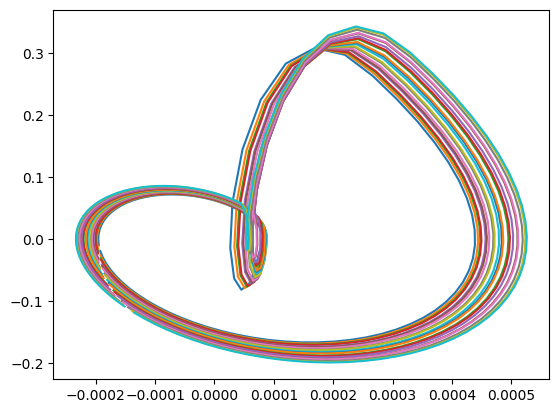

In [9]:
plt.figure(dpi=100)
plt.plot(RS_train[idxs[:20], 0, :, 10].T, RS_train[idxs[:20], 1, :, 10].T)
plt.show()

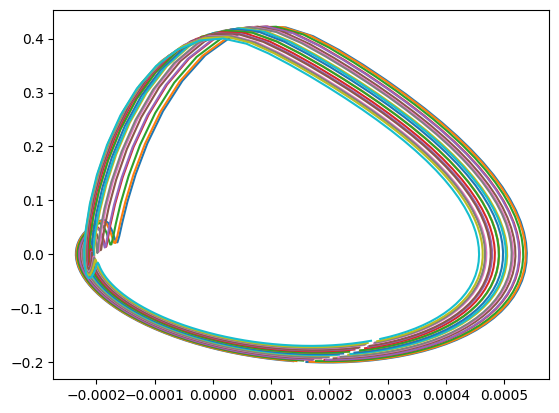

In [10]:
plt.figure(dpi=100)
plt.plot(RS_train[idxs[-20:], 0, :, 10].T, RS_train[idxs[-20:], 1, :, 10].T)
plt.show()

In [11]:
n_clusters = 2

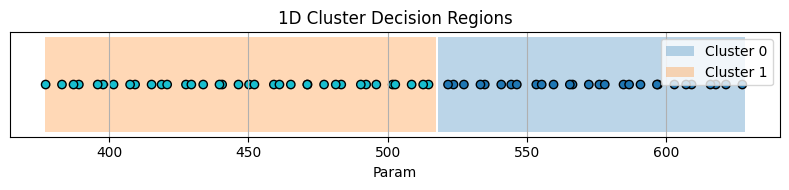

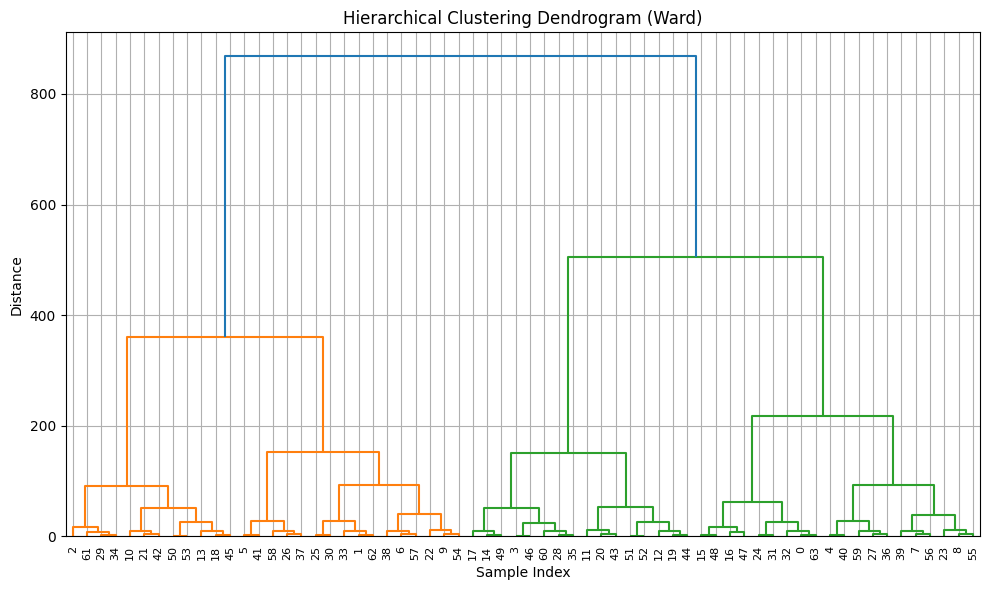

In [12]:
clust.find_clusters(n_clusters=n_clusters, method="ward")
clust.plot_decision_regions()
clust.plot_dendrogram()

for cluster in range(n_clusters):
    save_cluster(os.path.join(output_dir, "datasets", "Train"), cluster, FS_train, param_train, ft_train, disp_norm, vel_norm, ft_norm)
    save_cluster(os.path.join(output_dir, "datasets", "Val"), cluster, FS_val, param_val, ft_val, disp_norm, vel_norm, ft_norm)
    save_cluster(os.path.join(output_dir, "datasets", "Test"), cluster, FS_test, param_test, ft_test, disp_norm, vel_norm, ft_norm)

# End HERE if One Cluster

In [13]:
n_train_per_cluster = {i: n_train_per_cluster for i in range(n_clusters + 1)} #clust.estimate_points_per_cluster_by_density(density=200, min_per_cluster=20)

In [14]:
n_val_per_cluster = {i: n_val_per_cluster for i in range(n_clusters + 1)}
n_test_per_cluster = {i: n_test_per_cluster for i in range(n_clusters + 1)}

##### Generate Cluster Data

In [15]:
# Get clustered data
train_data_cl, train_param_cl, train_idx_cl = clust.get_clustered_data(FS_train, param_train)
new_params_train = clust.balance_cluster_points(param_train, min_points=n_train_per_cluster, min_dist=3e-3, use_scaled_metric=True)
print("Train params calculated")

val_data_cl, val_param_cl, val_idx_cl = clust.get_clustered_data(FS_val, param_val)
new_params_val = clust.balance_cluster_points(param_val, min_points=n_val_per_cluster, min_dist=2e-4, use_scaled_metric=True)
print("Val params calculated")

test_data_cl, test_param_cl, test_idx_cl = clust.get_clustered_data(FS_test, param_test)
new_params_test = clust.balance_cluster_points(param_test, min_points=n_test_per_cluster, min_dist=1e-4, use_scaled_metric=True)
print("Test params calculated")

Train params calculated
Val params calculated
Test params calculated


In [16]:
import os
import numpy as np
import joblib

from beam_fea_v2_pointload_shared_mesh import BeamFEAPointLoad

mesh_json_path = os.path.abspath(
    os.path.join(script_dir, "..", "Step_00_Create_Data", "beam_ellipse_shared.json")
)

nt = config_global["data"]["nt"]
ndof = FS_train.shape[-1]

fea = BeamFEAPointLoad(mesh_json_path=mesh_json_path)

# --------------------------------------------------
# helpers
# --------------------------------------------------

w_range = 2*np.pi*np.array([[60, 100]]) # Omega
T_range = 2*np.pi/w_range # Time period
tau_param = np.min(T_range)/5 # Impulse width
max_dt = tau_param/5 # dt

CKPT_EVERY = 1  # save after every generated sample

def solve_one_full(omega_val):
    omega_val = float(np.asarray(omega_val).squeeze())
    #tau_param = 2 * np.pi / (10 * omega_val)

    W, Wdot, ft, mesh, ib, W_full, Wdot_full, t_out, t, W_full_all, Wdot_full_all = fea.solve(
        omega=omega_val,
        tau=tau_param,
        nt=nt,
        n_periods=20,
        F0=1e4,
        beta_d=1e-3,
        load_type="pulse",
    )

    return W_full, Wdot_full, ft


def get_cluster_dir(split_name, idx_cluster):
    # cluster folders are inside Train/Val/Test
    return os.path.join(output_dir, "datasets", split_name, f"{idx_cluster}")


def ensure_cluster_dir(split_name, idx_cluster):
    cluster_dir = get_cluster_dir(split_name, idx_cluster)
    os.makedirs(cluster_dir, exist_ok=True)
    return cluster_dir


def get_partial_ckpt_path(split_name, idx_cluster):
    cluster_dir = ensure_cluster_dir(split_name, idx_cluster)
    return os.path.join(cluster_dir, "partial_checkpoint.pkl")


def get_done_flag_path(split_name, idx_cluster):
    cluster_dir = ensure_cluster_dir(split_name, idx_cluster)
    return os.path.join(cluster_dir, "DONE")


def get_final_snapshot_path(split_name, idx_cluster):
    cluster_dir = ensure_cluster_dir(split_name, idx_cluster)
    return os.path.join(cluster_dir, "snapshot_data.npy")


def get_final_param_path(split_name, idx_cluster):
    cluster_dir = ensure_cluster_dir(split_name, idx_cluster)
    return os.path.join(cluster_dir, "params.npy")


def get_final_forcing_path(split_name, idx_cluster):
    cluster_dir = ensure_cluster_dir(split_name, idx_cluster)
    return os.path.join(cluster_dir, "forcing.npy")


def atomic_joblib_dump(obj, path):
    tmp_path = path + ".tmp"
    joblib.dump(obj, tmp_path)
    os.replace(tmp_path, path)


def atomic_npy_save(path, arr):
    tmp_path = path + ".tmp.npy"
    np.save(tmp_path, arr)
    os.replace(tmp_path, path)


def final_cluster_files_exist(split_name, idx_cluster):
    return (
        os.path.exists(get_final_snapshot_path(split_name, idx_cluster))
        and os.path.exists(get_final_param_path(split_name, idx_cluster))
        and os.path.exists(get_final_forcing_path(split_name, idx_cluster))
    )


def cluster_done(split_name, idx_cluster):
    # treat either explicit DONE flag OR all 3 final files as done
    return os.path.exists(get_done_flag_path(split_name, idx_cluster)) or final_cluster_files_exist(split_name, idx_cluster)


def mark_cluster_done(split_name, idx_cluster):
    done_path = get_done_flag_path(split_name, idx_cluster)
    with open(done_path, "w") as f:
        f.write("done\n")


def remove_partial_ckpt(split_name, idx_cluster):
    ckpt_path = get_partial_ckpt_path(split_name, idx_cluster)
    if os.path.exists(ckpt_path):
        os.remove(ckpt_path)


def save_partial_checkpoint(split_name, idx_cluster, data, parameter, forcing, next_idx):
    ckpt = {
        "data": data,
        "parameter": parameter,
        "forcing": forcing,
        "next_idx": next_idx,
    }
    atomic_joblib_dump(ckpt, get_partial_ckpt_path(split_name, idx_cluster))


def load_partial_checkpoint(split_name, idx_cluster):
    ckpt_path = get_partial_ckpt_path(split_name, idx_cluster)
    if os.path.exists(ckpt_path):
        return joblib.load(ckpt_path)
    return None


def save_cluster_original_npy_format(split_name, idx_cluster, data, parameter, forcing):
    """
    Writes the final files in the original cluster subfolder layout:
      Train/<cluster_id>/snapshot_data.npy
      Train/<cluster_id>/params.npy
      Train/<cluster_id>/forcing.npy
    """
    snapshot_path = get_final_snapshot_path(split_name, idx_cluster)
    param_path = get_final_param_path(split_name, idx_cluster)
    forcing_path = get_final_forcing_path(split_name, idx_cluster)

    atomic_npy_save(snapshot_path, data)
    atomic_npy_save(param_path, parameter)
    atomic_npy_save(forcing_path, forcing)


def build_or_resume_split_cluster(
    split_name,
    idx_cluster,
    existing_data_list,
    existing_param_list,
    existing_idx_cl,
    existing_ft_all,
    new_params_list,
):
    cluster_dir = ensure_cluster_dir(split_name, idx_cluster)

    # Case 1: already finished in a previous run
    if cluster_done(split_name, idx_cluster):
        print(f"[SKIP] {split_name} cluster {idx_cluster} already complete at {cluster_dir}")
        remove_partial_ckpt(split_name, idx_cluster)
        return

    c_count = len(existing_data_list[idx_cluster])
    d_count = len(new_params_list[idx_cluster])
    n_total = c_count + d_count

    ckpt = load_partial_checkpoint(split_name, idx_cluster)

    if ckpt is not None:
        data = ckpt["data"]
        parameter = ckpt["parameter"]
        forcing = ckpt["forcing"]
        start_idx = int(ckpt["next_idx"])
        print(f"[RESUME] {split_name} cluster {idx_cluster} from index {start_idx}/{n_total}")
    else:
        data = np.zeros((n_total, 2, nt, ndof), dtype=np.float64)
        parameter = np.zeros((n_total, 1), dtype=np.float64)
        forcing = np.zeros((n_total, nt, 2), dtype=np.float64)

        # preload the already-existing samples from the original cluster content
        if c_count != 0:
            data[:c_count] = np.asarray(existing_data_list[idx_cluster])
            parameter[:c_count] = np.asarray(existing_param_list[idx_cluster]).reshape(-1, 1)
            forcing[:c_count] = existing_ft_all[existing_idx_cl[idx_cluster]]

        start_idx = c_count

        # Save initialization checkpoint immediately
        save_partial_checkpoint(split_name, idx_cluster, data, parameter, forcing, start_idx)
        print(f"[INIT] {split_name} cluster {idx_cluster} initialized at {cluster_dir}")

    # Generate only missing new samples
    for j in range(start_idx, n_total):
        local_idx = j - c_count + 1
        print(f"Cluster {idx_cluster} | {split_name} | {local_idx}/{d_count}")

        omega_val = new_params_list[idx_cluster][j - c_count]
        W_full, Wdot_full, ft = solve_one_full(omega_val)

        data[j, 0] = W_full
        data[j, 1] = Wdot_full
        forcing[j] = ft
        parameter[j, 0] = float(np.asarray(omega_val).squeeze())

        if ((j - start_idx + 1) % CKPT_EVERY == 0) or (j == n_total - 1):
            save_partial_checkpoint(split_name, idx_cluster, data, parameter, forcing, j + 1)

    # Finalize to the original .npy layout in the cluster subfolder
    save_cluster_original_npy_format(split_name, idx_cluster, data, parameter, forcing)
    mark_cluster_done(split_name, idx_cluster)
    remove_partial_ckpt(split_name, idx_cluster)

    print(f"[DONE] {split_name} cluster {idx_cluster} saved to final npy files in {cluster_dir}")

    del data, parameter, forcing


# --------------------------------------------------
# make top-level directories and save metadata
# --------------------------------------------------

os.makedirs(os.path.join(output_dir, "datasets", "Train"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "datasets", "Val"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "datasets", "Test"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "clustering"), exist_ok=True)

joblib.dump(clust, os.path.join(output_dir, "clustering", "cluster_model.pkl"))

config_global["data"]["n_clusters"] = n_clusters
save_config(config_file, config_global)

# --------------------------------------------------
# main generation loop
# --------------------------------------------------

for i in range(n_clusters):
    build_or_resume_split_cluster(
        split_name="Train",
        idx_cluster=i,
        existing_data_list=train_data_cl,
        existing_param_list=train_param_cl,
        existing_idx_cl=train_idx_cl,
        existing_ft_all=ft_train,
        new_params_list=new_params_train,
    )

    build_or_resume_split_cluster(
        split_name="Val",
        idx_cluster=i,
        existing_data_list=val_data_cl,
        existing_param_list=val_param_cl,
        existing_idx_cl=val_idx_cl,
        existing_ft_all=ft_val,
        new_params_list=new_params_val,
    )

    build_or_resume_split_cluster(
        split_name="Test",
        idx_cluster=i,
        existing_data_list=test_data_cl,
        existing_param_list=test_param_cl,
        existing_idx_cl=test_idx_cl,
        existing_ft_all=ft_test,
        new_params_list=new_params_test,
    )

[SKIP] Train cluster 0 already complete at c:\Users\haida\Desktop\beam_node_optimized_hole_center_omega\beam_node_optimized_hole_center_omega\Examples\elliptic_hole_omega\Outputs\datasets\Train\0
[SKIP] Val cluster 0 already complete at c:\Users\haida\Desktop\beam_node_optimized_hole_center_omega\beam_node_optimized_hole_center_omega\Examples\elliptic_hole_omega\Outputs\datasets\Val\0
[SKIP] Test cluster 0 already complete at c:\Users\haida\Desktop\beam_node_optimized_hole_center_omega\beam_node_optimized_hole_center_omega\Examples\elliptic_hole_omega\Outputs\datasets\Test\0
[SKIP] Train cluster 1 already complete at c:\Users\haida\Desktop\beam_node_optimized_hole_center_omega\beam_node_optimized_hole_center_omega\Examples\elliptic_hole_omega\Outputs\datasets\Train\1
[SKIP] Val cluster 1 already complete at c:\Users\haida\Desktop\beam_node_optimized_hole_center_omega\beam_node_optimized_hole_center_omega\Examples\elliptic_hole_omega\Outputs\datasets\Val\1
[SKIP] Test cluster 1 already 

In [17]:
# Build cluster-local basis matrices using the fixed global sensor placement
sp_global = sensor_processing(FS_train[:, 1], config_global)
_, _, _, global_sensor_placement = sp_global.load(output_dir)
global_sensor_dof_indices = sp_global.sensor_dof_indices.copy()

cluster_matrix_root = os.path.join("compression_matrices", "clusters")

for i in range(n_clusters):
    FS_train_cluster, _, _, _, _, _ = load_dataset(
        os.path.join(output_dir, "datasets", "Train", str(i)),
        normalize=False,
    )

    sp_cluster = sensor_processing(FS_train_cluster[:, 1], config_global)
    sp_cluster.set_sensor_placement(global_sensor_placement, global_sensor_dof_indices)
    sp_cluster.save(output_dir, matrix_subdir=os.path.join(cluster_matrix_root, str(i)))

    print(
        f"[BASIS] cluster {i}: "
        f"A_Mat {sp_cluster.A_Mat.shape}, "
        f"C_Mat {sp_cluster.C_Mat.shape}, "
        f"pinv_Theta {sp_cluster.pinv_Theta.shape}"
    )


[BASIS] cluster 0: A_Mat (6650, 13), C_Mat (100, 6650), pinv_Theta (13, 100)
[BASIS] cluster 1: A_Mat (6650, 13), C_Mat (100, 6650), pinv_Theta (13, 100)
